**Importing Libraries**

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

**Load Dataset**

In [4]:
df = pd.read_csv("diabetes.csv")
print('Dataset Shape:', df.shape)
df.head()

Dataset Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
print("Dataset Info:")
print(df.info())
print("\nStatistical Summary:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

Statistical Summary:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


**Duplicate Check**

In [6]:
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")
if duplicates > 0:
    df.drop_duplicates(inplace=True)


Number of duplicate rows: 0


**Null Value Handling**

It is identified that columns like Glucose, BloodPressure, SkinThickness, Insulin, and BMI contained zero values, which are medically impossible. These can be replaced with the median of their respective columns.

In [7]:
zero_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("Zero counts before treatment:")
print((df[zero_columns] == 0).sum())

for col in zero_columns:
    median = df[col].median()
    df[col] = df[col].replace(0, median)

print("\nZero counts after treatment:")
print((df[zero_columns] == 0).sum())

Zero counts before treatment:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Zero counts after treatment:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


**Exploratory Data Analysis**

**Feature Distribution using Histogram**

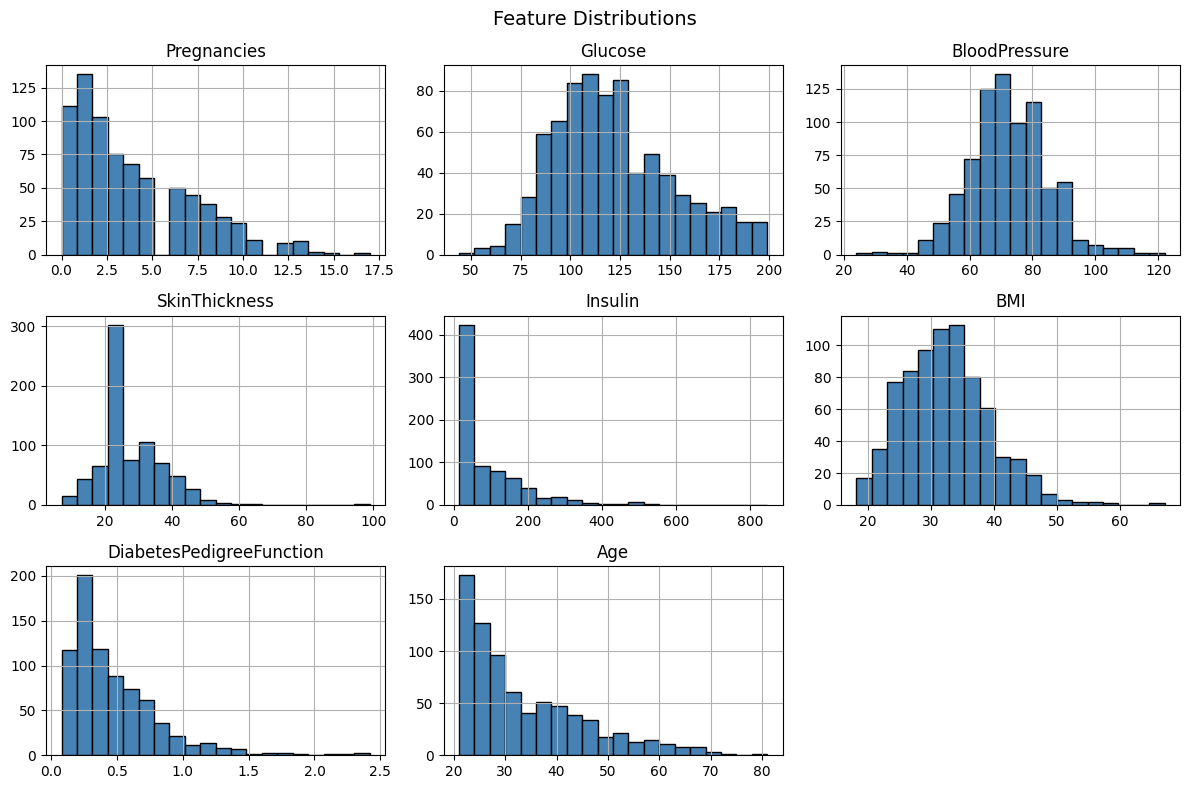

In [26]:
df.drop('Outcome', axis=1).hist(figsize=(12, 8), bins=20, color='steelblue', edgecolor='black')
plt.suptitle('Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

CountPlot - to see distribution of target variable

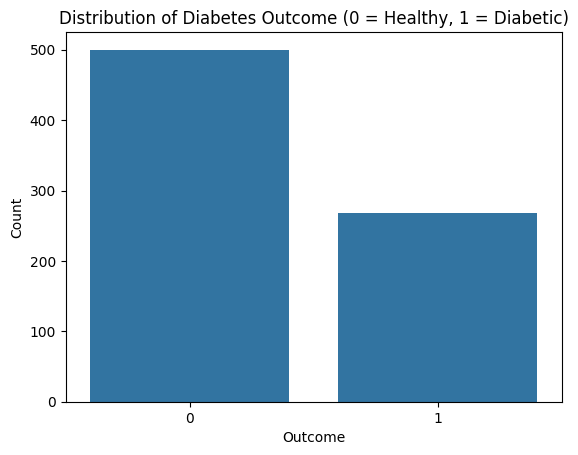

In [10]:
plt.figure()
sns.countplot(x='Outcome', data=df)
plt.title('Distribution of Diabetes Outcome (0 = Healthy, 1 = Diabetic)')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()

Here it shows roughly 500 people are non-diabetic and approx. 250 people are diabetic , there is a slight class imbalance.

**Correlation Heatmap**

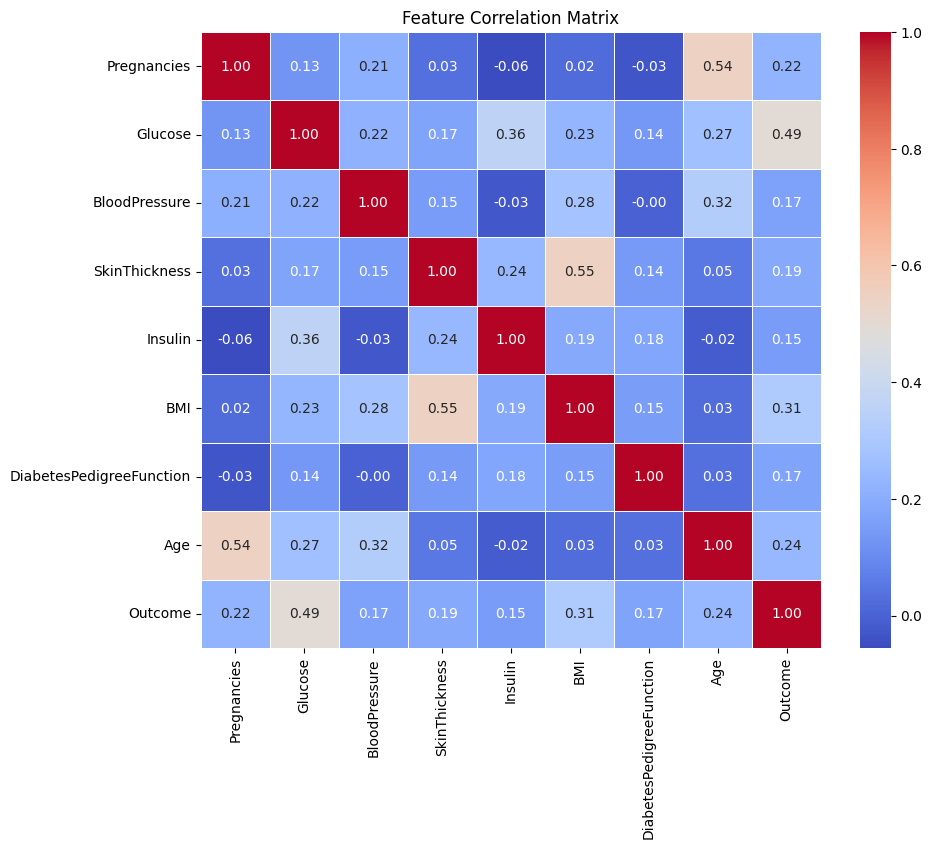

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

As we can see Glucose is the most correlated to the outcome

**Split and Scale Data**

In [12]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Training samples: 614
Testing samples:  154


**Training Models - Logistic Regression and Random Forest**

In [13]:
# Logistic Regression
lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
print("Logistic Regression trained!")

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest trained!")

Logistic Regression trained!
Random Forest trained!


**Evaluation Metrics**

In [19]:
def evaluate_model(name, y_true, y_pred):
    print(f"  {name}")
    print(f"  Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_true, y_pred):.4f}")
    print(f"  Recall    : {recall_score(y_true, y_pred):.4f}")
    print(f"  F1-Score  : {f1_score(y_true, y_pred):.4f}")
    print(f"\nClassification Report:\n")
    print(classification_report(y_true, y_pred))
    print(f"{'='*45}")
    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)

**Evaluation Metrics - Logistic Regression**

In [20]:
evaluate_model("Logistic Regression", y_test, y_pred_lr)

  Logistic Regression
  Accuracy  : 0.7662
  Precision : 0.6792
  Recall    : 0.6545
  F1-Score  : 0.6667

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.83      0.82        99
           1       0.68      0.65      0.67        55

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.74       154
weighted avg       0.76      0.77      0.77       154


Confusion Matrix:
[[82 17]
 [19 36]]


**Evaluation Metrics for Random Forest**

In [21]:
evaluate_model("Random Forest", y_test, y_pred_rf)

  Random Forest
  Accuracy  : 0.7532
  Precision : 0.6491
  Recall    : 0.6727
  F1-Score  : 0.6607

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154


Confusion Matrix:
[[79 20]
 [18 37]]


**Feature Importance**

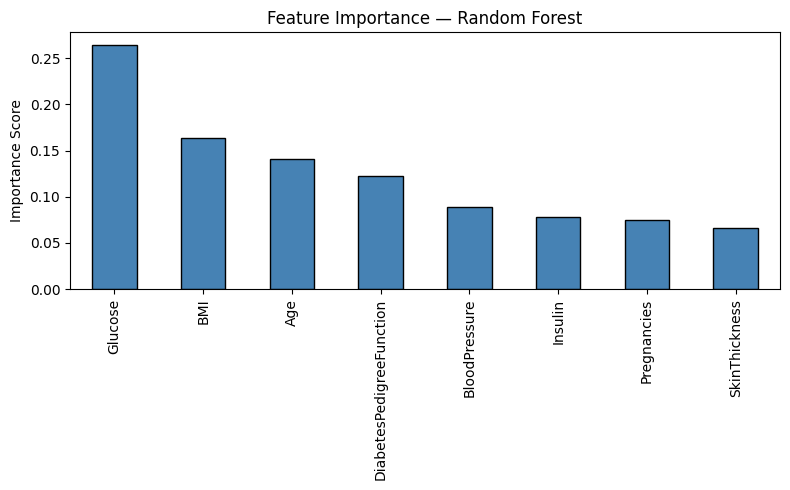

Top features:
 Glucose                     0.264943
BMI                         0.163291
Age                         0.141010
DiabetesPedigreeFunction    0.122428
BloodPressure               0.089150
Insulin                     0.077839
Pregnancies                 0.074988
SkinThickness               0.066351
dtype: float64


In [27]:
feature_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
feature_imp.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Feature Importance — Random Forest')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

print("Top features:\n", feature_imp)

Save the model

In [24]:
joblib.dump(lr, "logistic_regression_diabetes.pkl")
joblib.dump(rf, "random_forest_diabetes.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Models saved successfully!")

Models saved successfully!


In [25]:
# from google.colab import files

# files.download("logistic_regression_diabetes.pkl")
# files.download("random_forest_diabetes.pkl")
# files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>